# BC03 — Machine Learning : prédire la présence d'un oiseau (notebook de démonstration)

## De quoi parle-t-on ?

On arrive au cœur du projet. BC01 a construit une **grille** : pour chaque semaine, chaque petite
zone et chaque espèce, un `0` (pas vu) ou un `1` (vu). BC02 a montré que la **saison** compte
beaucoup et que la **météo seule** compte peu.

Ici, on demande à un ordinateur d'**apprendre tout seul**, à partir de milliers d'exemples passés,
à prédire ce `0` ou ce `1` pour une situation nouvelle (une semaine, un endroit, une météo). En
apprentissage automatique on appelle ça une **classification binaire** : ranger chaque situation
dans une des deux cases *présent* / *absent*.

## Pourquoi ce bloc ?

Le référentiel RNCP demande de savoir **entraîner, évaluer et comparer** plusieurs modèles de
prédiction sur des données **structurées** (un tableau de colonnes numériques), et surtout
d'**interpréter correctement** leurs résultats — y compris leurs limites. C'est exactement ce
qu'on fait ici, avec un piège célèbre à comprendre : quand une classe est très rare (ici 2 % de
présences), un modèle peut sembler « excellent » sans rien avoir appris.

## Comment suivre ce notebook

1. **Charger** la grille + la météo (produites par BC01).
2. **Préparer** les données : séparer les *features* (ce qu'on donne au modèle) de la *cible*
   (ce qu'on veut prédire).
3. **Séparer** un jeu d'entraînement et un jeu de test.
4. **Entraîner 3 modèles**, du plus simple au plus complexe.
5. **Comparer** avec les bonnes mesures — et voir le piège de l'accuracy.
6. **Matrice de confusion** : les 4 types d'erreurs.
7. **Courbe ROC / AUC**.
8. **Valider** le modèle retenu : sur-apprend-il ?
9. **Quelles variables** comptent le plus ?
10. **Bonus non supervisé** : regrouper les zones de présence (K-Means).

Comme les autres notebooks du projet, celui-ci rejoue le **vrai code du bloc**
([`run.py`](run.py), [`gestion_modeles.py`](gestion_modeles.py), [`segmentation.py`](segmentation.py)),
morceau par morceau.

## 0. Préparation

On rend le code du projet importable (dossier `commun/` **et** le dossier de ce bloc, pour pouvoir
réutiliser `preparer_features`, `construire_modeles`… tels quels), puis on importe les outils.

In [1]:
import sys
from pathlib import Path

_racine = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "commun").is_dir())
_bloc = _racine / "blocs" / "bc03_machine_learning"
for _p in (str(_racine), str(_bloc)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

%matplotlib inline
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

from commun.config import REPERTOIRE_MODELES, ParametresML
from commun.chargement import charger_grille_hebdomadaire, charger_meteo_traitee
from run import preparer_features, construire_modeles            # le vrai code de BC03
from gestion_modeles import GestionnaireModeles
from segmentation import segmenter_zones_densite

print("Racine du projet :", _racine)

Racine du projet : C:\Users\rasmi\Projects\projet_rncp\oiseaux_migrateurs_npdc


## 1. Charger les données de BC01

BC03 ne relit jamais GBIF ni Open-Meteo : il part des **fichiers Parquet** produits par BC01
(versionnés dans le dépôt, donc disponibles après un simple clone).

In [2]:
df_grille = charger_grille_hebdomadaire()
df_meteo = charger_meteo_traitee()

print(f"Grille : {len(df_grille):,} lignes  ({df_grille['presence'].mean()*100:.1f} % de présences)".replace(",", " "))
print(f"Météo  : {len(df_meteo):,} jours".replace(",", " "))
df_grille.head(3)

Grille : 681 408 lignes  (2.3 % de présences)
Météo  : 2 192 jours


,annee,semaine,espece,lat_discrete,lon_discrete,nombre_observations,presence
0,2019,1,hirondelle_rustique,51.4,3.9,0.0,0
1,2019,1,hirondelle_rustique,51.4,2.6,0.0,0
2,2019,1,hirondelle_rustique,51.4,3.5,0.0,0


## 2. Préparer les *features* (X) et la *cible* (y)

En Machine Learning, on sépare toujours deux choses dans le tableau :

- les **features** (variables explicatives) : ce qu'on **donne** au modèle → ici l'**année**, la
  **semaine**, la **position** (`lat_discrete`, `lon_discrete`), et les **7 variables météo** de la
  semaine ;
- la **cible** (*target*) : ce qu'on veut **prédire** → la colonne `presence` (0 ou 1).

La fonction `preparer_features` de [`run.py`](run.py) fait le travail : elle calcule la moyenne
météo **par semaine**, la rattache à la grille, et remplace les rares valeurs manquantes par la
médiane de leur colonne (choix simple et robuste, on ne perd aucune ligne).

In [3]:
X, y, noms_features = preparer_features(df_grille, df_meteo)

print("Features :", noms_features)
print("Forme de X :", X.shape)
print("Répartition de y :", y.value_counts().to_dict(), f"  ->  {y.mean()*100:.1f} % de présences")
X.head(3)

2026-09-08 15:16:37 | INFO     | run:preparer_features:59 - Preparation features...
2026-09-08 15:16:37 | INFO     | run:preparer_features:63 -   Fusion des variables meteo hebdomadaires...


2026-09-08 15:16:37 | INFO     | run:preparer_features:79 -   Variables meteo ajoutees : ['temperature_max', 'temperature_min', 'temperature_moyenne', 'precipitation_sum', 'vent_max', 'humidite_moyenne', 'pression_moyenne']


2026-09-08 15:16:37 | INFO     | run:preparer_features:88 -   Features retenues : ['annee', 'semaine', 'lat_discrete', 'lon_discrete', 'temperature_max', 'temperature_min', 'temperature_moyenne', 'precipitation_sum', 'vent_max', 'humidite_moyenne', 'pression_moyenne']
2026-09-08 15:16:37 | INFO     | run:preparer_features:89 -   Shape X : (681408, 11)
2026-09-08 15:16:37 | INFO     | run:preparer_features:90 -   Distribution y : {0: 665505, 1: 15903}
Features : ['annee', 'semaine', 'lat_discrete', 'lon_discrete', 'temperature_max', 'temperature_min', 'temperature_moyenne', 'precipitation_sum', 'vent_max', 'humidite_moyenne', 'pression_moyenne']
Forme de X : (681408, 11)
Répartition de y : {0: 665505, 1: 15903}   ->  2.3 % de présences


,annee,semaine,lat_discrete,lon_discrete,temperature_max,temperature_min,temperature_moyenne,precipitation_sum,vent_max,humidite_moyenne,pression_moyenne
0,2019,1,51.4,3.9,6.5,3.216667,5.0,0.083333,16.0,82.0,1037.95
1,2019,1,51.4,2.6,6.5,3.216667,5.0,0.083333,16.0,82.0,1037.95
2,2019,1,51.4,3.5,6.5,3.216667,5.0,0.083333,16.0,82.0,1037.95


**Ce que ça donne.** 11 colonnes en entrée (`annee`, `semaine`, `lat_discrete`, `lon_discrete` +
7 variables météo), et une cible très **déséquilibrée** : environ 2 % de `1`, 98 % de `0`. Ce
déséquilibre est le fil rouge de la suite.

## 3. Séparer un jeu d'entraînement et un jeu de test

Si on entraînait le modèle sur **toutes** les données puis qu'on le testait sur ces mêmes données,
on ne saurait jamais s'il a **compris** un phénomène général ou s'il a juste **appris par cœur**
les exemples (c'est le *surapprentissage*).

C'est la logique d'un examen : on révise avec des annales (le jeu d'**entraînement**), et on est
noté sur un sujet **jamais vu** (le jeu de **test**). On met de côté **20 %** des données pour le
test. Le découpage est **stratifié** : la même proportion de présences dans les deux jeux, pour ne
pas fausser la comparaison.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=ParametresML.TEST_SIZE,       # 0.2
    random_state=ParametresML.RANDOM_STATE, # 42 -> résultat reproductible
    stratify=y,
)
print(f"Entraînement : {len(X_train):,} lignes  ({y_train.mean()*100:.2f} % de présences)".replace(",", " "))
print(f"Test         : {len(X_test):,} lignes  ({y_test.mean()*100:.2f} % de présences)".replace(",", " "))

Entraînement : 545 126 lignes  (2.33 % de présences)
Test         : 136 282 lignes  (2.33 % de présences)


## 4. Entraîner 3 modèles, du plus simple au plus complexe

On compare volontairement **trois algorithmes** de complexité croissante — démarche classique : on
part d'un modèle simple et transparent (la *référence*), puis on regarde si des modèles plus
complexes apportent un vrai gain.

| Modèle | Comment il « raisonne », en une image |
|---|---|
| **Régression logistique** | Trace une frontière (une équation) qui sépare au mieux les cas *présent* des cas *absent*. Comme un trait de marqueur sur un nuage de points bicolore. |
| **Forêt aléatoire** | Construit des centaines d'« arbres de décision » (suites de questions « la température dépasse-t-elle 12 °C ? »…), chacun un peu différent, puis fait **voter** tous les arbres. Comme demander l'avis à 100 experts indépendants. |
| **XGBoost** | Construit aussi des arbres, mais **un par un** : chaque nouvel arbre corrige les erreurs des précédents. Comme un élève qui refait un exercice raté en ciblant ses fautes. |

Les 3 sont définis dans `construire_modeles` de [`run.py`](run.py), avec exactement les
hyperparamètres de `commun/config.py` (`ParametresML`). Chaque modèle est précédé d'une
**normalisation** des colonnes (`StandardScaler`), regroupée avec lui dans un `Pipeline`.

In [5]:
gestionnaire = GestionnaireModeles(REPERTOIRE_MODELES)
modeles, resultats = {}, {}

for nom, pipeline in construire_modeles().items():
    pipeline.fit(X_train, y_train)                 # entraînement
    resultats[nom] = gestionnaire.evaluer_modele(pipeline, X_test, y_test, nom)   # évaluation sur le test
    modeles[nom] = pipeline

print("\nLes 3 modèles sont entraînés et évalués.")

2026-09-08 15:16:39 | INFO     | gestion_modeles:evaluer_modele:49 - Evaluation modele : regression_logistique
2026-09-08 15:16:39 | INFO     | gestion_modeles:evaluer_modele:69 -   Accuracy : 0.9767
2026-09-08 15:16:39 | INFO     | gestion_modeles:evaluer_modele:70 -   F1-Score : 0.0000
2026-09-08 15:16:39 | INFO     | gestion_modeles:evaluer_modele:72 -   AUC-ROC  : 0.7695


2026-09-08 15:17:12 | INFO     | gestion_modeles:evaluer_modele:49 - Evaluation modele : foret_aleatoire


2026-09-08 15:17:12 | INFO     | gestion_modeles:evaluer_modele:69 -   Accuracy : 0.9767
2026-09-08 15:17:12 | INFO     | gestion_modeles:evaluer_modele:70 -   F1-Score : 0.0013
2026-09-08 15:17:12 | INFO     | gestion_modeles:evaluer_modele:72 -   AUC-ROC  : 0.9012


2026-09-08 15:17:17 | INFO     | gestion_modeles:evaluer_modele:49 - Evaluation modele : xgboost


2026-09-08 15:17:17 | INFO     | gestion_modeles:evaluer_modele:69 -   Accuracy : 0.9774
2026-09-08 15:17:17 | INFO     | gestion_modeles:evaluer_modele:70 -   F1-Score : 0.0783
2026-09-08 15:17:17 | INFO     | gestion_modeles:evaluer_modele:72 -   AUC-ROC  : 0.9131

Les 3 modèles sont entraînés et évalués.


## 5. Comparer : quelles mesures utiliser ?

Trois indicateurs classiques, calculés sur le **jeu de test** :

- **Accuracy (exactitude)** : proportion de prédictions correctes, toutes confondues. Le plus
  intuitif — et, on va le voir, le plus **trompeur** ici.
- **F1-score** : combine la capacité à **ne pas rater** les vraies présences et à **ne pas se
  tromper** quand on en annonce une. Contrairement à l'accuracy, il ne peut pas être élevé « par
  accident » sur des classes déséquilibrées.
- **AUC-ROC** : mesure si le modèle **classe bien** les situations par probabilité décroissante
  (mettre les vraies présences devant), indépendamment du seuil de décision. `1,0` = parfait,
  `0,5` = hasard.

In [6]:
df_comparaison = (pd.DataFrame(resultats).T[["accuracy", "f1_score", "auc_roc"]]
                  .sort_values("auc_roc", ascending=False))
df_comparaison.round(4)

,accuracy,f1_score,auc_roc
xgboost,0.9774,0.0783,0.9131
foret_aleatoire,0.9767,0.0013,0.9012
regression_logistique,0.9767,0.0000,0.7695


### Le piège de l'accuracy

**Analogie médicale.** Un test de dépistage d'une maladie rare (1 personne sur 100). Un test
« paresseux » qui répond *toujours* « non malade » a déjà **99 % de bonnes réponses** — et pourtant
il ne détecte **jamais** un seul cas réel. Il est inutile.

Ici c'est pareil : **~98 % des cases de la grille sont des absences**. Un modèle qui prédirait
« absence » à chaque fois aurait ~98 % d'accuracy sans avoir rien appris. La cellule suivante
regarde donc, pour chaque modèle, ce qu'il fait **réellement sur les rares présences** du jeu de
test.

In [7]:
for nom, m in resultats.items():
    presences_reelles = m["tp"] + m["fn"]
    print(f"{nom} :")
    print(f"   accuracy officielle        : {m['accuracy']*100:.2f} %")
    print(f"   vraies présences détectées : {m['tp']} / {presences_reelles} "
          f"({100*m['tp']/presences_reelles:.1f} %)")
    print(f"   fausses alertes            : {m['fp']}")
    print()

regression_logistique :
   accuracy officielle        : 97.67 %
   vraies présences détectées : 0 / 3181 (0.0 %)
   fausses alertes            : 0

foret_aleatoire :
   accuracy officielle        : 97.67 %
   vraies présences détectées : 2 / 3181 (0.1 %)
   fausses alertes            : 0

xgboost :
   accuracy officielle        : 97.74 %
   vraies présences détectées : 131 / 3181 (4.1 %)
   fausses alertes            : 33



**Ce que ça nous apprend.** Régression logistique et Forêt aléatoire ont une accuracy magnifique…
mais ne détectent **quasiment aucune** présence réelle : elles se contentent de prédire « absent »,
exactement comme le test médical paresseux. **XGBoost est le seul à détecter une partie des vraies
présences** — imparfaitement, mais nettement mieux. C'est la raison technique pour laquelle **XGBoost
est retenu** comme modèle de production (`modeles/pipeline_ml.pkl`), même si son accuracy n'est pas
la plus haute.

## 6. La matrice de confusion : les 4 cas possibles

| | prédit « absence » | prédit « présence » |
|---|---|---|
| **réellement absent** | vrai négatif ✔ | **fausse alerte** (faux positif) |
| **réellement présent** | **oiseau raté** (faux négatif) | vrai positif ✔ |

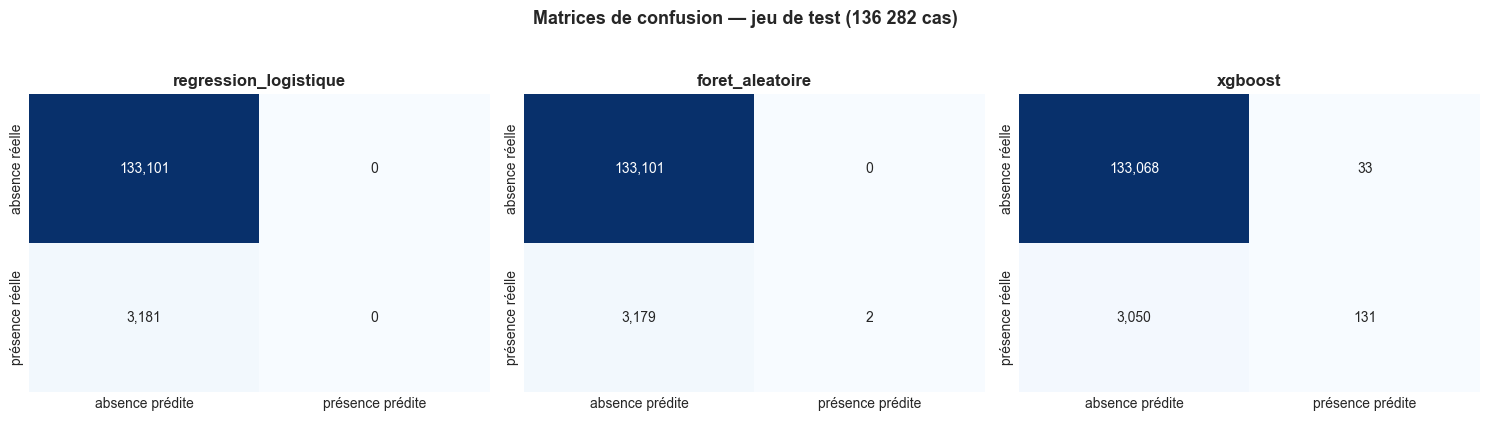

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nom, pipeline) in zip(axes, modeles.items()):
    cm = confusion_matrix(y_test, pipeline.predict(X_test))
    sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["absence prédite", "présence prédite"],
                yticklabels=["absence réelle", "présence réelle"])
    ax.set_title(nom, fontweight="bold")
plt.suptitle(f"Matrices de confusion — jeu de test ({len(y_test):,} cas)".replace(",", " "),
             fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

**Lecture.** La case en bas à droite (« présence réelle / présence prédite ») est **vide** pour la
Régression logistique et la Forêt aléatoire, et non nulle pour XGBoost : lui seul « ose » prédire
des présences.

## 7. La courbe ROC et l'AUC

Un modèle ne renvoie pas directement 0/1 : il renvoie une **probabilité**, qu'on transforme en
décision avec un **seuil** (0,5 par défaut). La **courbe ROC** montre ce qui se passerait pour
*tous les seuils à la fois* — pratique pour comparer sans se fixer arbitrairement sur un seuil.
Plus la courbe colle au coin supérieur gauche, meilleur est le modèle ; la diagonale = le hasard.

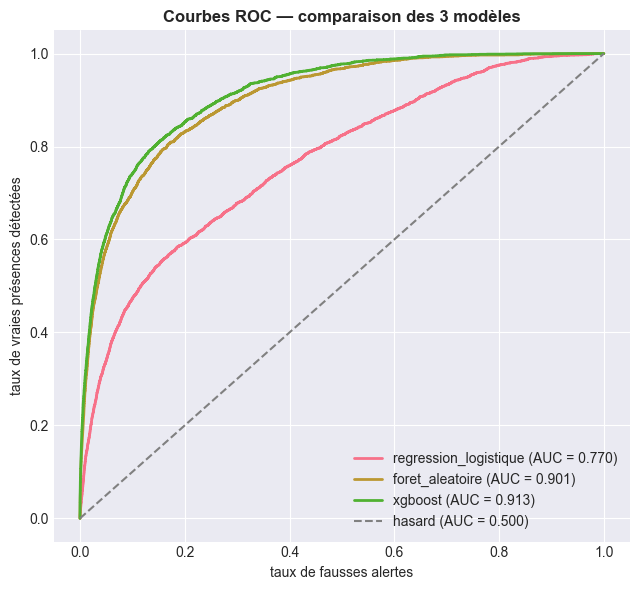

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for nom, pipeline in modeles.items():
    proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, linewidth=2, label=f"{nom} (AUC = {resultats[nom]['auc_roc']:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", label="hasard (AUC = 0.500)")
ax.set_xlabel("taux de fausses alertes")
ax.set_ylabel("taux de vraies présences détectées")
ax.set_title("Courbes ROC — comparaison des 3 modèles", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Lecture.** Les 3 courbes sont au-dessus de la diagonale : même les modèles faibles en F1 ont
appris *quelque chose*. XGBoost a la courbe la plus proche du coin idéal → c'est lui qui **ordonne
le mieux** les situations par probabilité de présence.

## 8. Valider le modèle retenu (XGBoost) : sur-apprend-il ?

Deux vérifications, reprises de `valider_modele_retenu` dans [`run.py`](run.py) :

1. **Validation croisée 5 plis** (*5-fold*) : on découpe le jeu d'entraînement en 5, on entraîne
   sur 4 morceaux et on évalue sur le 5ᵉ, 5 fois. Si l'AUC est stable d'un pli à l'autre, le modèle
   est **robuste**.
2. **Écart train / test** : si le modèle est bien meilleur sur les données qu'il a vues
   (entraînement) que sur celles qu'il n'a pas vues (test), c'est du **sur-apprentissage**. On veut
   un écart faible (≤ 0,05).

In [10]:
xgb = clone(modeles["xgboost"])
cv = StratifiedKFold(n_splits=ParametresML.N_SPLITS_CV, shuffle=True, random_state=ParametresML.RANDOM_STATE)

scores = []
for idx_tr, idx_val in cv.split(X_train, y_train):
    pli = clone(xgb).fit(X_train.iloc[idx_tr], y_train.iloc[idx_tr])
    scores.append(roc_auc_score(y_train.iloc[idx_val], pli.predict_proba(X_train.iloc[idx_val])[:, 1]))
scores = pd.Series(scores)
print(f"AUC-ROC {ParametresML.N_SPLITS_CV}-fold : {scores.mean():.3f} +/- {scores.std(ddof=0):.3f}")

modeles["xgboost"].fit(X_train, y_train)
auc_train = roc_auc_score(y_train, modeles["xgboost"].predict_proba(X_train)[:, 1])
auc_test = roc_auc_score(y_test, modeles["xgboost"].predict_proba(X_test)[:, 1])
print(f"AUC-ROC train {auc_train:.3f} | test {auc_test:.3f} | écart {auc_train - auc_test:.3f}")
print("-> écart faible : pas de sur-apprentissage marqué."
      if auc_train - auc_test <= 0.05 else "-> écart élevé : sur-apprentissage probable.")

AUC-ROC 5-fold : 0.910 +/- 0.003


AUC-ROC train 0.915 | test 0.913 | écart 0.002
-> écart faible : pas de sur-apprentissage marqué.


**Ce que ça nous apprend.** L'AUC est quasi identique d'un pli à l'autre (écart-type minuscule) et
l'écart train/test est très faible : le modèle est **stable** et **ne sur-apprend pas**.

## 9. Quelles variables comptent le plus pour XGBoost ?

XGBoost peut indiquer, pour chaque variable d'entrée, à quel point elle l'a aidé pendant
l'entraînement. C'est une façon d'ouvrir la « boîte noire » et de vérifier que le modèle s'appuie
sur des facteurs qui **ont un sens**. (Dans [`run.py`](run.py) : `analyser_influence_variables`.)

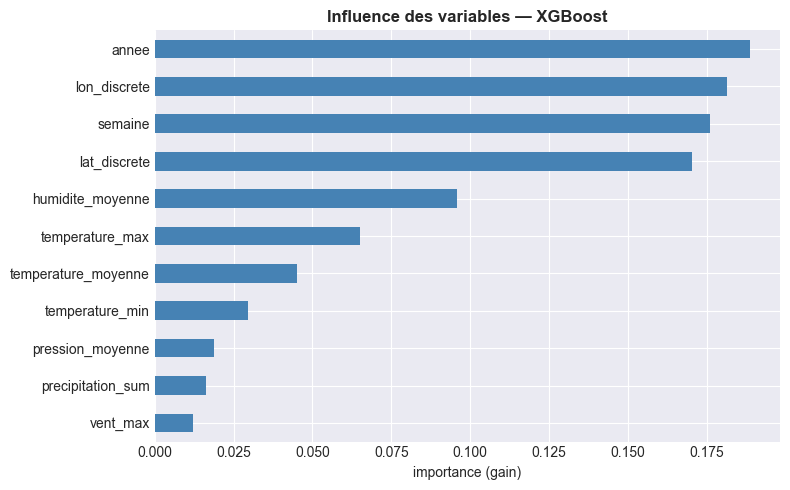

annee                  0.189
lon_discrete           0.182
semaine                0.176
lat_discrete           0.170
humidite_moyenne       0.096
temperature_max        0.065
temperature_moyenne    0.045
temperature_min        0.030
pression_moyenne       0.019
precipitation_sum      0.016
vent_max               0.012
dtype: float32

In [11]:
importances = pd.Series(
    modeles["xgboost"].named_steps["modele"].feature_importances_, index=noms_features
).sort_values()

importances.plot.barh(figsize=(8, 5), color="steelblue")
plt.title("Influence des variables — XGBoost", fontweight="bold")
plt.xlabel("importance (gain)")
plt.tight_layout()
plt.show()
importances.sort_values(ascending=False).round(3)

**Ce que ça nous apprend.** Ce sont les variables **spatiales et temporelles** (position, semaine
de l'année) qui pèsent le plus — cohérent avec BC02 : la saison a un effet fort, la météo seule un
effet faible. Le modèle a donc appris **exactement** ce que l'analyse exploratoire laissait
pressentir : *« quand et où »* compte plus que *« quel temps il fait »*.

## 10. Bonus non supervisé : regrouper les zones de présence (K-Means)

Le référentiel demande aussi de savoir **segmenter** une base en groupes homogènes **sans variable
cible** (apprentissage *non supervisé*). Ici : regrouper les mailles où les oiseaux sont présents en
quelques **zones géographiques**.

Le nombre de zones `K` n'est pas fixé à l'avance : `segmentation.py` teste `K` de 2 à 8 et retient
celui qui maximise le **score de silhouette** (une note de qualité du regroupement).

In [12]:
zones = segmenter_zones_densite(df_grille)
zones

2026-09-08 15:17:43 | INFO     | segmentation:segmenter_zones_densite:40 - 
--- SEGMENTATION NON SUPERVISEE (zones de densite) ---


2026-09-08 15:17:49 | INFO     | segmentation:choisir_nombre_zones:29 -   K=2 : silhouette=0.582


2026-09-08 15:17:55 | INFO     | segmentation:choisir_nombre_zones:29 -   K=3 : silhouette=0.532


2026-09-08 15:18:00 | INFO     | segmentation:choisir_nombre_zones:29 -   K=4 : silhouette=0.530


2026-09-08 15:18:05 | INFO     | segmentation:choisir_nombre_zones:29 -   K=5 : silhouette=0.448


2026-09-08 15:18:09 | INFO     | segmentation:choisir_nombre_zones:29 -   K=6 : silhouette=0.430


2026-09-08 15:18:14 | INFO     | segmentation:choisir_nombre_zones:29 -   K=7 : silhouette=0.453


2026-09-08 15:18:18 | INFO     | segmentation:choisir_nombre_zones:29 -   K=8 : silhouette=0.435
2026-09-08 15:18:18 | INFO     | segmentation:choisir_nombre_zones:31 -   -> 2 zones retenues (silhouette=0.582)
2026-09-08 15:18:18 | INFO     | segmentation:segmenter_zones_densite:66 -   2 zones -> zones_densite.csv


,latitude,longitude,cellules_presence
0,51.045916,3.468700,10591
1,50.395444,2.026017,5312


**Ce que ça nous apprend.** Les mailles de présence se regroupent naturellement en quelques zones,
dont on a le centre (lat/lon) et le nombre de mailles. C'est utile pour cibler des campagnes de
comptage : on sait *où* se concentrer.

## Récapitulatif — ce qu'il faut retenir

Reprenons le chemin parcouru :

1. On est parti de la **grille de BC01** et on a séparé *features* (année, semaine, position, météo)
   et *cible* (`presence`).
2. On a mis **20 %** des données de côté pour un test honnête.
3. On a entraîné **3 modèles** du plus simple au plus complexe.
4. L'**accuracy est trompeuse** ici (98 % en prédisant toujours « absent ») : le **F1-score** et
   l'**AUC-ROC** montrent que **seul XGBoost détecte réellement des présences** → il est retenu.
5. XGBoost est **stable** (validation croisée) et **ne sur-apprend pas** (écart train/test faible).
6. Ses variables les plus utiles sont la **position** et la **semaine** — cohérent avec BC02.
7. En bonus, un **K-Means** regroupe les mailles de présence en quelques zones.

| Point | Résultat |
|---|---|
| Modèle retenu | **XGBoost**, AUC-ROC ≈ 0,91 |
| Limite honnête | le **rappel** des vraies présences reste faible en valeur absolue (déséquilibre 98/2) |
| Piste | rééquilibrage des classes (SMOTE, déjà dans les dépendances) ou `class_weight="balanced"` |

**Et après ?** BC05 (industrialisation) va **exposer ce modèle** (`pipeline_ml.pkl`) via une API et
un tableau de bord, pour qu'une personne qui ne code pas puisse l'utiliser.

Le script [`run.py`](run.py) rejoue tout ça en une commande, **sauvegarde** les modèles et
`evaluations.csv`, et journalise chaque entraînement dans **MLflow** (`mlruns/`).